In [1]:
%pip install --quiet --disable-pip-version-check numpy==2.5.3 pandas==3.0.6 scikit-learn==1.9.1 scipy==1.18.1 matplotlib==3.11.2 threadpoolctl==3.7.0

In [2]:
import hashlib
import io
import json
import re
import urllib.request
import zipfile
from datetime import datetime, timezone
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits
from IPython.display import Image, display

ROOT = Path.cwd()
FACTORS = ["Value", "Profitability", "Momentum"]
STRATEGIES = ["Equal weights", "Historical mean tilt", "Volatility rule", "Linear regime", "Flexible regime"]
FILES = {
    "factors": "Emerging_5_Factors_CSV.zip",
    "momentum": "Emerging_MOM_Factor_CSV.zip",
    "value_buckets": "Emerging_Markets_6_Portfolios_ME_BE-ME_CSV.zip",
    "profitability_buckets": "Emerging_Markets_6_Portfolios_ME_OP_CSV.zip",
    "momentum_buckets": "Emerging_Markets_6_Portfolios_ME_Prior_12_2_CSV.zip",
}
SETTINGS = {
    "training_months": 120,
    "signal_lag_months": 2,
    "volatility_months": 6,
    "market_return_months": 6,
    "correlation_months": 12,
    "states": 2,
    "prior_months": 24,
    "minimum_state_weight": 12,
    "favoured_factor_weight": 0.50,
    "other_factor_weight": 0.25,
    "cost_bps_per_traded_dollar": 10,
    "random_seed": 42,
    "initializations": 5,
    "covariance_regularization": 0.001,
    "as_of_date": "2026-10-04",
}

In [3]:
def download_data():
    folder = ROOT / "data"
    folder.mkdir(exist_ok=True)
    manifest_path = folder / "source_manifest.json"
    manifest = json.loads(manifest_path.read_text()) if manifest_path.exists() else []
    recorded = {row["file"]: row for row in manifest}
    for name in FILES.values():
        path = folder / name
        if not path.exists():
            url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/" + name
            with urllib.request.urlopen(url, timeout=60) as response:
                path.write_bytes(response.read())
            recorded[name] = {
                "file": name,
                "url": url,
                "retrieved_utc": datetime.now(timezone.utc).isoformat(),
                "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
            }
        if name not in recorded:
            raise ValueError(f"Missing source record for {name}.")
        if hashlib.sha256(path.read_bytes()).hexdigest() != recorded[name]["sha256"]:
            raise ValueError(f"The saved source file changed: {name}.")
    manifest_path.write_text(json.dumps(list(recorded.values()), indent=2), encoding="utf-8")
    return recorded

In [4]:
def read_monthly(path):
    with zipfile.ZipFile(path) as archive:
        member = next(name for name in archive.namelist() if name.lower().endswith(".csv"))
        lines = archive.read(member).decode("utf-8-sig").splitlines()
    first = next(i for i, line in enumerate(lines) if re.match(r"^\s*\d{6}\s*,", line))
    last = first
    while last < len(lines) and re.match(r"^\s*\d{6}\s*,", lines[last]):
        last += 1
    frame = pd.read_csv(io.StringIO("\n".join(lines[first - 1:last])), index_col=0)
    frame.columns = frame.columns.str.strip()
    frame.index = pd.to_datetime(frame.index.astype(str).str.strip(), format="%Y%m") + pd.offsets.MonthEnd(0)
    frame.index.name = "Month"
    frame = frame.apply(pd.to_numeric, errors="raise").replace([-99.99, -999], np.nan) / 100
    if not frame.index.is_unique or not frame.index.is_monotonic_increasing:
        raise ValueError("Source dates must be unique and ordered.")
    return frame

In [5]:
def load_data():
    download_data()
    tables = {key: read_monthly(ROOT / "data" / name) for key, name in FILES.items()}
    raw = tables["factors"]
    output = raw[["Mkt-RF", "RF", "HML", "RMW"]].copy()
    output["WML"] = tables["momentum"]["WML"]
    columns = {
        "Value": ("value_buckets", ["SMALL HiBM", "BIG HiBM"], ["SMALL LoBM", "BIG LoBM"], "HML"),
        "Profitability": ("profitability_buckets", ["SMALL HiOP", "BIG HiOP"], ["SMALL LoOP", "BIG LoOP"], "RMW"),
        "Momentum": ("momentum_buckets", ["SMALL HiPRIOR", "BIG HiPRIOR"], ["SMALL LoPRIOR", "BIG LoPRIOR"], "WML"),
    }
    for factor, (key, high, low, published) in columns.items():
        output[factor] = tables[key][high].mean(axis=1, skipna=False)
        reconstructed = tables[key][high].mean(axis=1, skipna=False) - tables[key][low].mean(axis=1, skipna=False)
        error = (reconstructed - output[published]).abs().dropna().max()
        if error > 0.000251:
            raise ValueError(f"The {published} reconstruction does not match the source.")
    output["Market"] = output["Mkt-RF"] + output["RF"]
    output = output.dropna()
    output = output.loc[output.index < pd.Timestamp(SETTINGS["as_of_date"]).replace(day=1)]
    expected = pd.period_range(output.index[0], output.index[-1], freq="M")
    if not output.index.to_period("M").equals(expected):
        raise ValueError("The common monthly data have gaps.")
    if not np.isfinite(output.to_numpy()).all() or (output[FACTORS] <= -1).any().any():
        raise ValueError("Invalid portfolio returns.")
    return output

In [6]:
def make_features(data, settings=SETTINGS):
    features = pd.DataFrame(index=data.index)
    features["Market volatility"] = data["Market"].rolling(settings["volatility_months"]).std() * np.sqrt(12)
    features["Market return"] = (1 + data["Market"]).rolling(settings["market_return_months"]).apply(np.prod, raw=True) - 1
    pairs = [data[a].rolling(settings["correlation_months"]).corr(data[b]) for a, b in combinations(["HML", "RMW", "WML"], 2)]
    features["Factor correlation"] = pd.concat(pairs, axis=1).mean(axis=1, skipna=False)
    return features

In [7]:
def modest_tilt(scores, settings=SETTINGS):
    scores = np.asarray(scores, dtype=float)
    if np.ptp(scores) < 1e-12:
        return np.full(3, 1 / 3)
    weights = np.full(3, settings["other_factor_weight"])
    weights[int(np.argmax(scores))] = settings["favoured_factor_weight"]
    return weights

In [8]:
def conditional_weights(responsibilities, current, outcomes, settings=SETTINGS):
    relative = outcomes - outcomes.mean(axis=1, keepdims=True)
    overall = relative.mean(axis=0)
    targets = []
    for state in range(responsibilities.shape[1]):
        sample_weights = responsibilities[:, state]
        support = sample_weights.sum()
        if support < settings["minimum_state_weight"]:
            targets.append(np.full(3, 1 / 3))
        else:
            scores = (sample_weights @ relative + settings["prior_months"] * overall) / (support + settings["prior_months"])
            targets.append(modest_tilt(scores, settings))
    return np.asarray(current) @ np.asarray(targets)

In [9]:
def walk_forward(data, settings=SETTINGS):
    features = make_features(data, settings)
    lag = settings["signal_lag_months"]
    future_returns = data[FACTORS].shift(-lag)
    rows, diagnostics = [], []
    with threadpool_limits(limits=1):
        for position in range(len(data)):
            signal_position = position - lag
            last_train_position = signal_position - lag
            if last_train_position < 0:
                continue
            training = features.iloc[:last_train_position + 1].dropna().tail(settings["training_months"])
            if len(training) < settings["training_months"]:
                continue
            signal = features.iloc[[signal_position]]
            if signal.isna().any().any():
                continue
            outcomes = future_returns.loc[training.index].to_numpy()
            scaler = StandardScaler().fit(training)
            train_x = scaler.transform(training)
            signal_x = scaler.transform(signal)
            date = data.index[position]
            targets = {"Equal weights": np.full(3, 1 / 3), "Historical mean tilt": modest_tilt(outcomes.mean(axis=0), settings)}
            cutoff = training["Market volatility"].median()
            rule_states = (training["Market volatility"] > cutoff).astype(int).to_numpy()
            rule_current = int(signal["Market volatility"].iloc[0] > cutoff)
            targets["Volatility rule"] = conditional_weights(np.eye(2)[rule_states], np.eye(2)[rule_current], outcomes, settings)
            diagnostic = {
                "Month": date, "Signal month": data.index[signal_position],
                "Training feature end": training.index[-1],
                "Training outcome end": data.index[last_train_position + lag],
                "Rule high volatility": rule_current,
            }
            for name, covariance in [("Linear regime", "tied"), ("Flexible regime", "full")]:
                model = GaussianMixture(
                    n_components=settings["states"], covariance_type=covariance,
                    reg_covar=settings["covariance_regularization"], n_init=settings["initializations"],
                    max_iter=500, random_state=settings["random_seed"], init_params="k-means++",
                ).fit(train_x)
                probabilities = model.predict_proba(train_x)
                current = model.predict_proba(signal_x)[0]
                volatility = training["Market volatility"].to_numpy()
                state_volatility = (probabilities.T @ volatility) / probabilities.sum(axis=0)
                higher_volatility = int(np.argmax(state_volatility))
                diagnostic[name + " high-volatility probability"] = float(current[higher_volatility])
                diagnostic[name + " converged"] = bool(model.converged_)
                targets[name] = conditional_weights(probabilities, current, outcomes, settings) if model.converged_ else np.full(3, 1 / 3)
            for strategy, weights in targets.items():
                rows.append({"Month": date, "Strategy": strategy, **dict(zip(FACTORS, weights))})
            diagnostics.append(diagnostic)
    if not rows:
        raise ValueError("Not enough data for the chosen training window.")
    return pd.DataFrame(rows).set_index(["Month", "Strategy"]), pd.DataFrame(diagnostics).set_index("Month")

In [10]:
def portfolio_returns(data, weights, cost_bps=10):
    rows = []
    for strategy in STRATEGIES:
        targets = weights.xs(strategy, level="Strategy")
        previous = np.zeros(3)
        for date, target in targets.iterrows():
            target = target.to_numpy(dtype=float)
            returns = data.loc[date, FACTORS].to_numpy(dtype=float)
            traded = float(np.abs(target - previous).sum())
            gross = float(target @ returns)
            cost = traded * cost_bps / 10000
            net = (1 - cost) * (1 + gross) - 1
            rows.append({"Month": date, "Strategy": strategy, "Gross return": gross, "Net return": net, "Traded notional": traded})
            previous = target * (1 + returns) / (1 + gross)
    return pd.DataFrame(rows).set_index(["Month", "Strategy"]).sort_index()

In [11]:
def summarize(results, risk_free):
    rows = []
    for strategy in STRATEGIES:
        sample = results.xs(strategy, level="Strategy")
        returns = sample["Net return"]
        excess = returns - risk_free.reindex(returns.index)
        wealth = (1 + returns).cumprod()
        peaks = np.maximum.accumulate(np.r_[1.0, wealth.to_numpy()])[1:]
        rows.append({
            "Strategy": strategy,
            "Annual return %": (wealth.iloc[-1] ** (12 / len(returns)) - 1) * 100,
            "Volatility %": returns.std(ddof=1) * np.sqrt(12) * 100,
            "Sharpe ratio": excess.mean() / excess.std(ddof=1) * np.sqrt(12),
            "Max drawdown %": (wealth.to_numpy() / peaks - 1).min() * 100,
            "Annual traded notional": sample["Traded notional"].mean() * 12,
        })
    return pd.DataFrame(rows).set_index("Strategy")

In [12]:
def paired_uncertainty(results, repetitions=2000, reference="Equal weights"):
    frame = results["Net return"].unstack("Strategy")
    random = np.random.default_rng(42)
    length = len(frame)
    offsets = np.arange(12)
    indices = (random.integers(0, length, (repetitions, int(np.ceil(length / 12)), 1)) + offsets) % length
    indices = indices.reshape(repetitions, -1)[:, :length]
    rows = []
    for name in [item for item in STRATEGIES if item != reference]:
        difference = (frame[name] - frame[reference]).to_numpy()
        samples = difference[indices].mean(axis=1) * 12 * 100
        lower, upper = np.quantile(samples, [0.025, 0.975])
        rows.append({"Strategy": name, "Annualized mean advantage pp": difference.mean() * 12 * 100,
                     "95% lower pp": lower, "95% upper pp": upper})
    return pd.DataFrame(rows).set_index("Strategy")

In [13]:
def save_outputs(data, weights, diagnostics, results, metrics):
    folder = ROOT / "results"
    folder.mkdir(exist_ok=True)
    data.to_csv(folder / "monthly_inputs.csv", date_format="%Y-%m-%d")
    weights.to_csv(folder / "factor_weights.csv", date_format="%Y-%m-%d")
    diagnostics.to_csv(folder / "regime_signals.csv", date_format="%Y-%m-%d")
    results.to_csv(folder / "portfolio_returns.csv", date_format="%Y-%m-%d")
    metrics.to_csv(folder / "performance.csv")
    uncertainty = paired_uncertainty(results)
    uncertainty.to_csv(folder / "uncertainty.csv")
    controls = pd.concat({reference: paired_uncertainty(results, reference=reference).loc[["Flexible regime"]]
                          for reference in ["Historical mean tilt", "Volatility rule", "Linear regime"]}, names=["Reference"])
    controls.to_csv(folder / "model_comparisons.csv")
    sensitivity = pd.concat({cost: summarize(portfolio_returns(data, weights, cost), data["RF"]) for cost in [0, 10, 25]}, names=["Cost bps"])
    sensitivity.to_csv(folder / "cost_sensitivity.csv")
    dates = diagnostics.index
    halves = {"Earlier half": dates[:len(dates) // 2], "Later half": dates[len(dates) // 2:]}
    subperiods = pd.concat({label: summarize(results.loc[period], data["RF"]) for label, period in halves.items()}, names=["Period"])
    subperiods.to_csv(folder / "subperiods.csv")
    average_weights = weights.groupby("Strategy").mean().reindex(STRATEGIES)
    average_weights.to_csv(folder / "average_weights.csv")
    groups = (diagnostics["Flexible regime high-volatility probability"] >= 0.5).map({False: "Lower-volatility estimate", True: "Higher-volatility estimate"})
    regime_outcomes = data.loc[dates, ["Market"] + FACTORS].groupby(groups).agg(["count", "mean", "std"])
    regime_outcomes.to_csv(folder / "regime_outcomes.csv")
    return uncertainty, subperiods, average_weights

In [14]:
def plot_results(results, weights, diagnostics):
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    from matplotlib.ticker import PercentFormatter

    folder = ROOT / "results"
    plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
    dates = diagnostics.index
    interval = f"{dates[0]:%b %Y} to {dates[-1]:%b %Y}"
    palette = {"Equal weights": "#333333", "Historical mean tilt": "#999999", "Volatility rule": "#686868", "Linear regime": "#C58520", "Flexible regime": "#2463A6"}
    styles = {"Equal weights": "-", "Historical mean tilt": ":", "Volatility rule": "-.", "Linear regime": "--", "Flexible regime": "-"}
    fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True, layout="constrained")
    for name in STRATEGIES:
        returns = results.xs(name, level="Strategy")["Net return"]
        curve = pd.concat([pd.Series([1.0], index=[dates[0] - pd.offsets.MonthEnd(1)]), (1 + returns).cumprod()])
        axes[0].plot(curve.index, curve * 100, label=name, color=palette[name], linestyle=styles[name], linewidth=1.8)
        axes[1].plot(curve.index, curve / curve.cummax() - 1, color=palette[name], linestyle=styles[name], linewidth=1.4)
    axes[0].set_title("Emerging-market factor bucket portfolios", loc="left", fontweight="bold")
    axes[0].set_ylabel("Growth of 100 USD")
    axes[0].legend(ncol=2, frameon=False, fontsize=9, loc="upper left")
    axes[1].set_ylabel("Drawdown")
    axes[1].set_xlabel("Month")
    axes[1].yaxis.set_major_formatter(PercentFormatter(1))
    for axis in axes:
        axis.grid(axis="y", color="#e7e7e7", linewidth=0.7)
    fig.suptitle(f"{interval} | Monthly returns | 10 bps per traded dollar", fontsize=11)
    fig.savefig(folder / "performance.png", dpi=150)
    plt.close(fig)
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, layout="constrained")
    for name in ["Linear regime", "Flexible regime"]:
        axes[0].plot(dates, diagnostics[name + " high-volatility probability"], label=name, color=palette[name], linestyle=styles[name], linewidth=1.3)
    axes[0].set_title("Estimated regimes and factor weights", loc="left", fontweight="bold")
    axes[0].set_ylabel("Higher-volatility state\nprobability")
    axes[0].set_ylim(0, 1)
    axes[0].legend(frameon=False, loc="upper right")
    allocation = weights.xs("Flexible regime", level="Strategy")
    for name, color, style in zip(FACTORS, ["#2463A6", "#C58520", "#333333"], ["-", "--", ":"]):
        axes[1].plot(dates, allocation[name], label=name, color=color, linestyle=style, linewidth=1.4)
    axes[1].set_ylim(0, 0.6)
    axes[1].set_ylabel("Flexible regime allocation")
    axes[1].set_xlabel("Holding month")
    axes[1].legend(frameon=False, ncol=3, loc="upper right")
    for axis in axes:
        axis.yaxis.set_major_formatter(PercentFormatter(1))
        axis.grid(axis="y", color="#e7e7e7", linewidth=0.7)
    fig.suptitle(f"{interval} | Signals use data ending two months before each holding month", fontsize=10)
    fig.savefig(folder / "regimes_and_weights.png", dpi=150)
    plt.close(fig)

In [15]:
display(pd.Series(SETTINGS, name="Setting").to_frame())

,Setting
training_months,120
signal_lag_months,2
volatility_months,6
market_return_months,6
correlation_months,12
states,2
prior_months,24
minimum_state_weight,12
favoured_factor_weight,0.5
other_factor_weight,0.25


In [16]:
data = load_data()
display((data[FACTORS].head() * 100).round(3).rename_axis("Month; returns in %"))

,Value,Profitability,Momentum
Month; returns in %,,,
1991-07-31,0.635,-1.890,-2.235
1991-08-31,-0.700,-0.835,-1.760
1991-09-30,-3.495,-5.455,-1.985
1991-10-31,2.995,2.965,5.205
1991-11-30,0.365,6.360,-0.715


In [17]:
features = make_features(data)
display(features.dropna().head().round(4))

,Market volatility,Market return,Factor correlation
Month,,,
1992-06-30,0.1975,0.0230,-0.3304
1992-07-31,0.1358,-0.0632,-0.3202
1992-08-31,0.0957,-0.1359,-0.3223
1992-09-30,0.0978,-0.1239,-0.3409
1992-10-31,0.1376,-0.0775,-0.2768


In [18]:
weights, diagnostics = walk_forward(data)
display(diagnostics.head())

,Signal month,Training feature end,Training outcome end,Rule high volatility,Linear regime high-volatility probability,Linear regime converged,Flexible regime high-volatility probability,Flexible regime converged
Month,,,,,,,,
2002-09-30,2002-07-31,2002-05-31,2002-07-31,0,0.508437,True,2.372391e-26,True
2002-10-31,2002-08-31,2002-06-30,2002-08-31,0,0.503648,True,1.309453e-23,True
2002-11-30,2002-09-30,2002-07-31,2002-09-30,0,0.508215,True,2.149388e-36,True
2002-12-31,2002-10-31,2002-08-31,2002-10-31,1,0.514105,True,1.820701e-38,True
2003-01-31,2002-11-30,2002-09-30,2002-11-30,1,0.514206,True,7.824130e-28,True


In [19]:
results = portfolio_returns(data, weights, SETTINGS["cost_bps_per_traded_dollar"])
metrics = summarize(results, data["RF"])
uncertainty, subperiods, average_weights = save_outputs(data, weights, diagnostics, results, metrics)
plot_results(results, weights, diagnostics)
display(metrics.round(3))

,Annual return %,Volatility %,Sharpe ratio,Max drawdown %,Annual traded notional
Strategy,,,,,
Equal weights,14.137,19.355,0.700,-61.838,0.125
Historical mean tilt,14.525,19.577,0.712,-61.970,0.287
Volatility rule,14.567,19.582,0.714,-61.970,0.701
Linear regime,14.545,19.580,0.713,-61.970,0.286
Flexible regime,14.560,19.553,0.714,-62.154,0.641


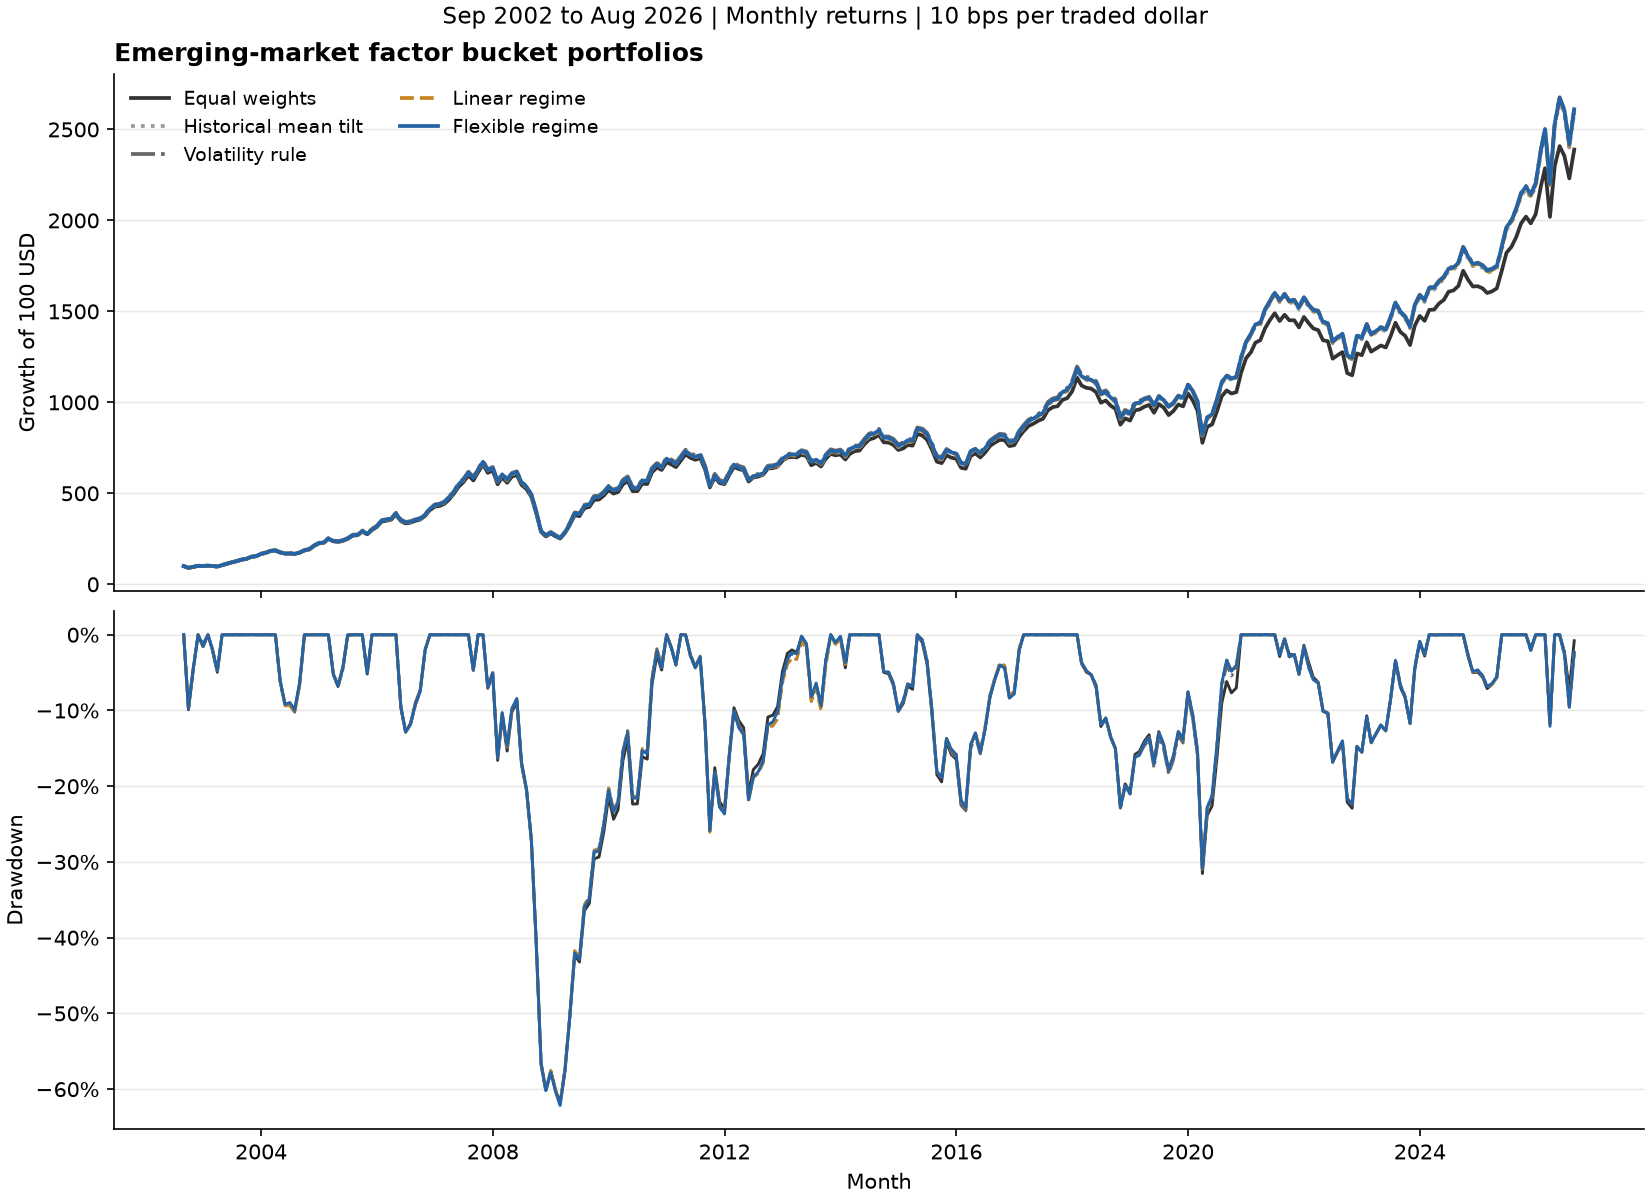

In [20]:
display(Image(filename=str(ROOT / "results" / "performance.png")))

In [21]:
controls = pd.read_csv(ROOT / "results" / "model_comparisons.csv").set_index(["Reference", "Strategy"])
display(controls.round(4))
display(uncertainty.round(4))

,,Annualized mean advantage pp,95% lower pp,95% upper pp
Reference,Strategy,,,
Historical mean tilt,Flexible regime,0.0261,-0.0691,0.1203
Volatility rule,Flexible regime,-0.0120,-0.1333,0.1065
Linear regime,Flexible regime,0.0084,-0.0813,0.0946


,Annualized mean advantage pp,95% lower pp,95% upper pp
Strategy,,,
Historical mean tilt,0.3856,0.0590,0.7580
Volatility rule,0.4237,0.0854,0.7898
Linear regime,0.4034,0.0773,0.7740
Flexible regime,0.4117,0.0907,0.7702


In [22]:
costs = pd.read_csv(ROOT / "results" / "cost_sensitivity.csv").set_index(["Cost bps", "Strategy"])
display(costs[["Annual return %", "Sharpe ratio", "Max drawdown %"]].round(3))

Annual return %  Sharpe ratio  Max drawdown %
Cost bps Strategy                                                           
0        Equal weights                  14.152         0.701         -61.834
         Historical mean tilt           14.558         0.713         -61.966
         Volatility rule                14.648         0.717         -61.966
         Linear regime                  14.578         0.714         -61.966
         Flexible regime                14.634         0.717         -62.072
10       Equal weights                  14.137         0.700         -61.838
         Historical mean tilt           14.525         0.712         -61.970
         Volatility rule                14.567         0.714         -61.970
         Linear regime                  14.545         0.713         -61.970
         Flexible regime                14.560         0.714         -62.154
25       Equal weights                  14.116         0.699         -61.844
         Historical mean tilt           14.476         0.710         -61.976
         Volatility rule                14.447         0.708         -61.976
         Linear regime                  14.496         0.710         -61.976
         Flexible regime                14.450         0.709         -62.276

In [23]:
test_dates = diagnostics.index
split = len(test_dates) // 2
print("Earlier half:", test_dates[0].date(), "to", test_dates[split - 1].date())
print("Later half:", test_dates[split].date(), "to", test_dates[-1].date())
display(subperiods[["Annual return %", "Sharpe ratio", "Max drawdown %"]].round(3))

Earlier half: 2002-09-30 to 2014-08-31
Later half: 2014-09-30 to 2026-08-31


Annual return %  Sharpe ratio  \
Period       Strategy                                              
Earlier half Equal weights                  19.181         0.851   
             Historical mean tilt           19.390         0.852   
             Volatility rule                19.572         0.859   
             Linear regime                  19.431         0.853   
             Flexible regime                19.486         0.857   
Later half   Equal weights                   9.307         0.515   
             Historical mean tilt            9.859         0.542   
             Volatility rule                 9.772         0.537   
             Linear regime                   9.859         0.542   
             Flexible regime                 9.838         0.541   

                                   Max drawdown %  
Period       Strategy                              
Earlier half Equal weights                -61.838  
             Historical mean tilt         -61.970  
             Volatility rule              -61.970  
             Linear regime                -61.970  
             Flexible regime              -62.154  
Later half   Equal weights                -31.528  
             Historical mean tilt         -30.776  
             Volatility rule              -31.223  
             Linear regime                -30.776  
             Flexible regime              -30.776

,Value,Profitability,Momentum
Average target weights (%),,,
Equal weights,33.33,33.33,33.33
Historical mean tilt,33.25,25.00,41.75
Volatility rule,33.51,25.00,41.49
Linear regime,33.11,25.00,41.89
Flexible regime,32.85,25.03,42.12


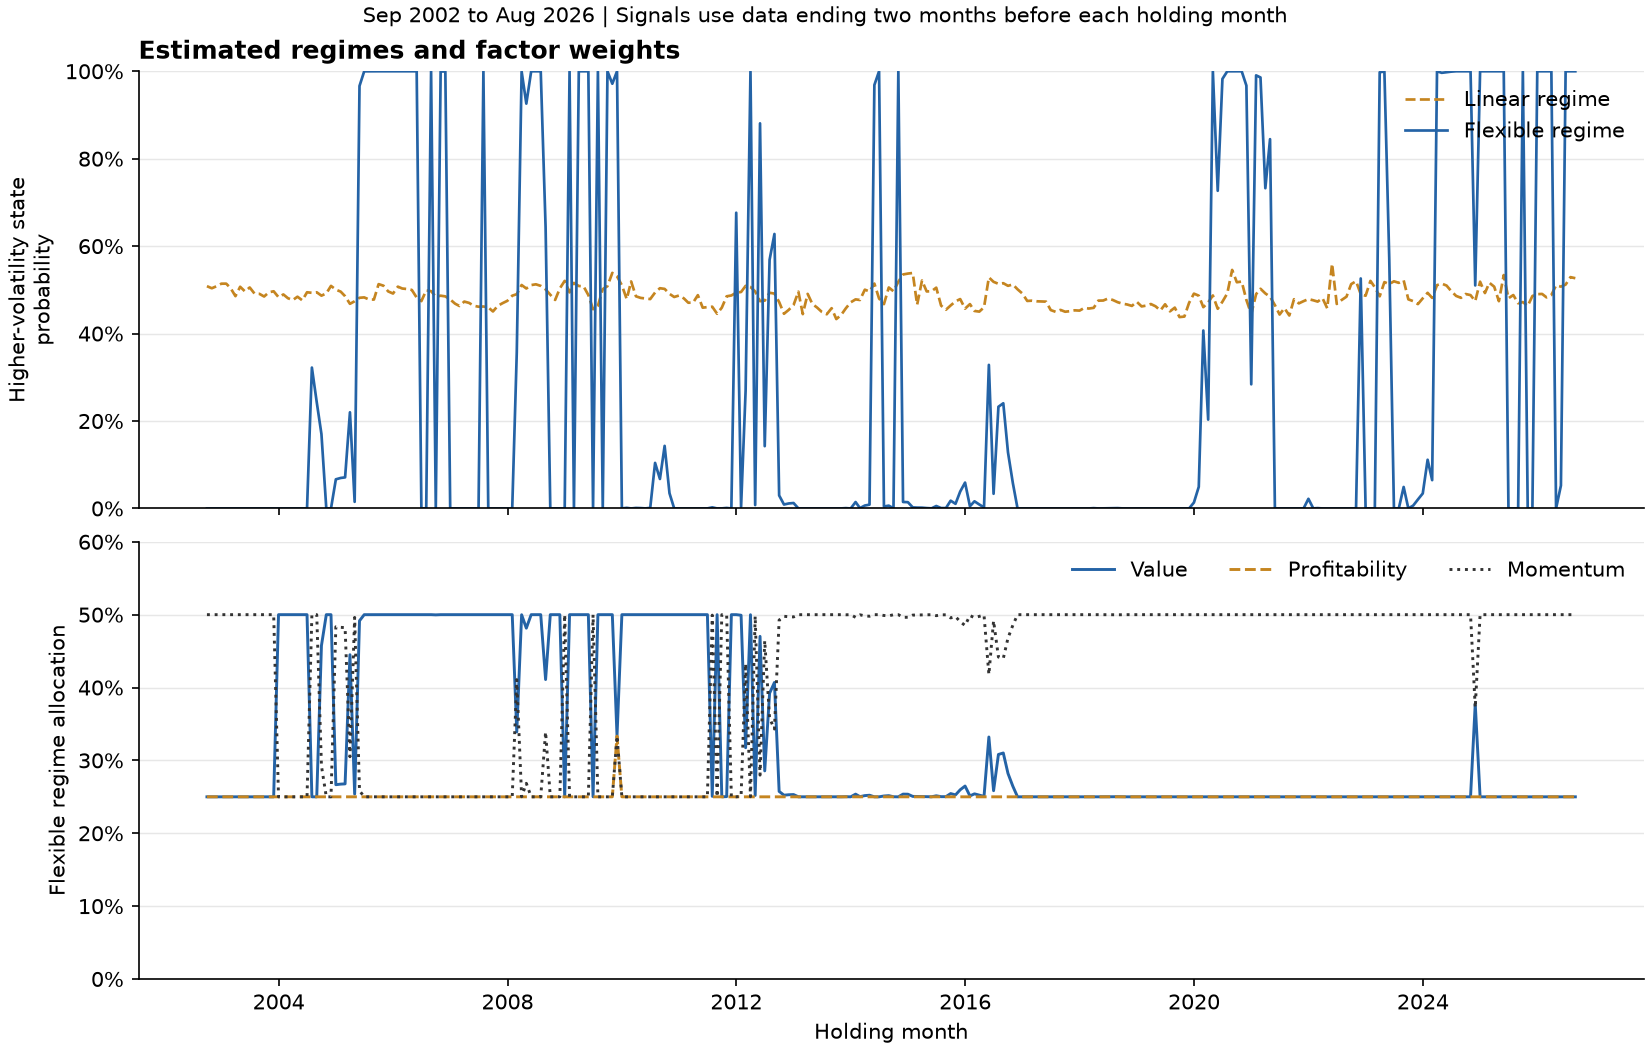

In [24]:
display((average_weights * 100).round(2).rename_axis("Average target weights (%)"))
display(Image(filename=str(ROOT / "results" / "regimes_and_weights.png")))

From September 2002 to August 2026, equal weights returned 14.14% a year after the assumed costs, compared with 14.56% for the flexible regime model and 14.53% for the historical-mean tilt. The flexible model still had a maximum drawdown of 62.15%. Its estimated annualized mean-return advantage over the historical-mean rule had a 95% bootstrap interval from -0.07 to 0.12 percentage points. That comparison matters more than showing a higher return than equal weights alone. We should judge the extra model against the simpler allocation rules, using these results as an initial study rather than proof of a dependable trading advantage.